In [52]:
# Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.mixture import GaussianMixture 

In [53]:
# Load the data
df = pd.read_csv('../data/processed/engineered_features.csv')

In [54]:
# Quick look at position distribution
print(df['Position'].value_counts())
print()

Position
D     721
C     678
LW    300
RW    247
F      37
W       6
Name: count, dtype: int64



In [55]:
def toi_to_float(x):
    if pd.isna(x):
        return None
    x = str(x).strip()
    if ':' in x:
        mins, secs = x.split(':')
        return float(mins) + float(secs) / 60
    return pd.to_numeric(x, errors='coerce')

df['Avg TOI'] = df['Avg TOI'].apply(toi_to_float)

In [56]:
# Split into forwards and defensemen

def classify_position(pos):
    pos = str(pos).strip()

    if pos == 'D':
        return 'D'
    elif pos == 'C':
        return 'F'
    elif pos in {'LW', 'RW', 'W', 'F', 'LW/RW'}:
        return 'F'
    else:
        return 'EXCLUDE'

df['Position Group'] = df['Position'].apply(classify_position)

df_fwd = df[df['Position Group'] == 'F'].copy()
df_def = df[df['Position Group'] == 'D'].copy()
excluded = df[df['Position Group'] == 'EXCLUDE'].copy()

print(f'Forwards  : {len(df_fwd):,} player-seasons')
print(f'Defenders : {len(df_def):,} player-seasons')
print(f'Excluded  : {len(excluded):,} player-seasons')

if len(excluded):
    print('\nExcluded labels:')
    print(excluded['Position'].value_counts())

Forwards  : 1,268 player-seasons
Defenders : 721 player-seasons
Excluded  : 0 player-seasons


For clustering, I restricted the population to player-seasons with at least 20 games played. I also required average time on ice of at least 10 minutes for forwards and 12 minutes for defensemen to reduce noise from limited-usage player-seasons.

In [57]:
# First-pass player filters for clustering population

MIN_GP = 20
MIN_TOI_FWD = 10
MIN_TOI_DEF = 12

df_fwd_filt = df_fwd[
    (df_fwd['Games Played'] >= MIN_GP) &
    (df_fwd['Avg TOI'] >= MIN_TOI_FWD)
].copy()

df_def_filt = df_def[
    (df_def['Games Played'] >= MIN_GP) &
    (df_def['Avg TOI'] >= MIN_TOI_DEF)
].copy()

print('Before filtering:')
print(f'Forwards  : {len(df_fwd):,}')
print(f'Defenders : {len(df_def):,}')

print('\nAfter filtering:')
print(f'Forwards  : {len(df_fwd_filt):,}')
print(f'Defenders : {len(df_def_filt):,}')

print('\nRetention:')
print(f'Forwards  : {len(df_fwd_filt) / len(df_fwd):.1%}')
print(f'Defenders : {len(df_def_filt) / len(df_def):.1%}')

Before filtering:
Forwards  : 1,268
Defenders : 721

After filtering:
Forwards  : 1,195
Defenders : 674

Retention:
Forwards  : 94.2%
Defenders : 93.5%


In [58]:
fwd_features = [
    'Age',
    'Avg TOI',
    'Ozone Start Pct',
    'Faceoff Pct',
    'Goals_per_60',
    'Assists_per_60',
    'Points_per_60',
    'Shots_on_Goal_per_60',
    'xGoals_per_60',
    'Hits_per_60',
    'Blocks_per_60',
    'Takeaways_pg',
    'Giveaways_pg',
    'Faceoff Impact_pg',
    'On Ice xGoals Diff_MP',
    'On Ice xGoals Ratio_MP',
    'Individual Zone Start Balance_MP',
    'Shooting Pct',
    'highDanger_Conversion'
]

X_fwd = df_fwd_filt[fwd_features].copy()

In [59]:
def_features = [
    'Age',
    'Avg TOI',
    'Ozone Start Pct',
    'Goals_per_60',
    'Assists_per_60',
    'Points_per_60',
    'Shots_on_Goal_per_60',
    'xGoals_per_60',
    'Hits_per_60',
    'Blocks_per_60',
    'Takeaways_pg',
    'Giveaways_pg',
    'On Ice xGoals Diff_MP',
    'On Ice xGoals Ratio_MP',
    'Individual Zone Start Balance_MP',
    'Shooting Pct',
    'highDanger_Conversion'
]

X_def = df_def_filt[def_features].copy()

In [60]:
print("Forward feature matrix shape:", X_fwd.shape)
print("Defense feature matrix shape:", X_def.shape)

print("\nMissing values in forwards:")
print(X_fwd.isna().sum()[X_fwd.isna().sum() > 0].sort_values(ascending=False))

print("\nMissing values in defense:")
print(X_def.isna().sum()[X_def.isna().sum() > 0].sort_values(ascending=False))

Forward feature matrix shape: (1195, 19)
Defense feature matrix shape: (674, 17)

Missing values in forwards:
Series([], dtype: int64)

Missing values in defense:
Series([], dtype: int64)


In [61]:
scaler_fwd = StandardScaler()
X_fwd_scaled = scaler_fwd.fit_transform(X_fwd)

scaler_def = StandardScaler()
X_def_scaled = scaler_def.fit_transform(X_def)

In [62]:
k_range = range(2, 11)

fwd_bic = []
fwd_aic = []

def_bic = []
def_aic = []

for k in k_range:
    gmm_fwd = GaussianMixture(n_components=k, random_state=42)
    gmm_fwd.fit(X_fwd_scaled)
    fwd_bic.append(gmm_fwd.bic(X_fwd_scaled))
    fwd_aic.append(gmm_fwd.aic(X_fwd_scaled))
    
    gmm_def = GaussianMixture(n_components=k, random_state=42)
    gmm_def.fit(X_def_scaled)
    def_bic.append(gmm_def.bic(X_def_scaled))
    def_aic.append(gmm_def.aic(X_def_scaled))

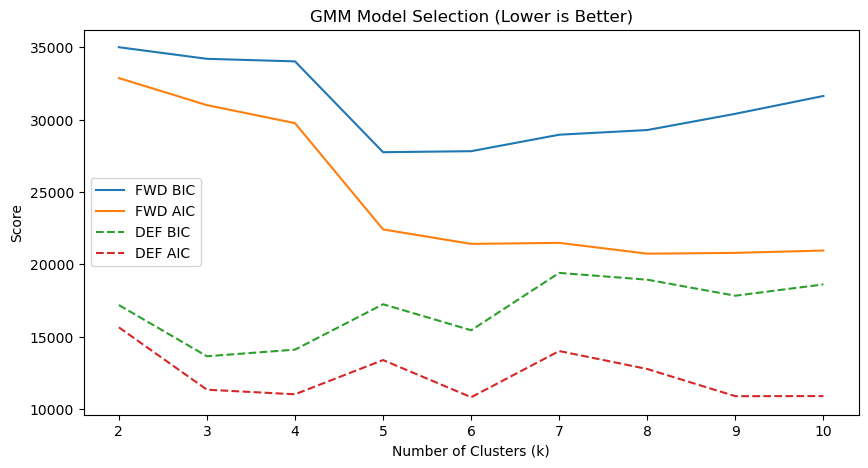

In [63]:
plt.figure(figsize=(10,5))

plt.plot(k_range, fwd_bic, label='FWD BIC')
plt.plot(k_range, fwd_aic, label='FWD AIC')
plt.plot(k_range, def_bic, label='DEF BIC', linestyle='--')
plt.plot(k_range, def_aic, label='DEF AIC', linestyle='--')

plt.xlabel('Number of Clusters (k)')
plt.ylabel('Score')
plt.title('GMM Model Selection (Lower is Better)')
plt.legend()
plt.show()

In [64]:
# Final models
gmm_fwd = GaussianMixture(n_components=5, random_state=42)
gmm_def = GaussianMixture(n_components=4, random_state=42)

fwd_clusters = gmm_fwd.fit_predict(X_fwd_scaled)
def_clusters = gmm_def.fit_predict(X_def_scaled)

In [65]:
df_fwd_filt['Cluster'] = fwd_clusters
df_def_filt['Cluster'] = def_clusters

In [66]:
fwd_summary = df_fwd_filt.groupby('Cluster')[fwd_features].mean()
print("Forward Cluster Summary:")
display(fwd_summary)

# Get cluster probabilities
fwd_probs = gmm_fwd.predict_proba(X_fwd_scaled)

# Attach probabilities to dataframe
for i in range(fwd_probs.shape[1]):
    df_fwd_filt[f'Cluster_{i}_prob'] = fwd_probs[:, i]

# Show top 5 players per cluster
for k in range(gmm_fwd.n_components):
    print(f"\n=== Forward Cluster {k} (Top 5 most representative players) ===")
    
    display(
        df_fwd_filt
        .sort_values(f'Cluster_{k}_prob', ascending=False)
        [['Player', 'Team', 'Season', f'Cluster_{k}_prob']]
        .head(4)
    )

Forward Cluster Summary:


,Age,Avg TOI,Ozone Start Pct,Faceoff Pct,Goals_per_60,Assists_per_60,Points_per_60,Shots_on_Goal_per_60,xGoals_per_60,Hits_per_60,Blocks_per_60,Takeaways_pg,Giveaways_pg,Faceoff Impact_pg,On Ice xGoals Diff_MP,On Ice xGoals Ratio_MP,Individual Zone Start Balance_MP,Shooting Pct,highDanger_Conversion
Cluster,,,,,,,,,,,,,,,,,,,
0,25.942308,15.359215,48.300000,46.172596,0.755193,1.018251,1.773443,6.288097,0.738530,4.882634,1.938271,0.381645,0.383568,3.092487,-0.549928,0.992551,-7.430288,10.998077,0.864516
1,26.125926,15.920679,52.634815,0.000000,0.987119,1.268984,2.256103,9.765527,1.131599,6.047804,1.864061,0.481684,0.599415,0.000000,12.699111,1.235536,88.770370,11.925185,0.917001
2,28.347826,12.517391,39.634783,37.960870,0.665851,0.683559,1.328989,3.307072,0.389883,6.447212,2.431560,0.192921,0.229917,2.154797,-8.810870,0.676725,-100.304348,11.404348,1.080989
3,26.914894,18.686879,54.714096,48.027128,1.161290,1.569490,2.730781,8.563611,1.065704,2.812706,1.720982,0.568235,0.680337,5.121481,22.353963,1.389331,107.917553,13.603723,0.912511
4,24.863636,14.649848,51.353636,40.296364,0.806421,1.054562,1.860983,12.587849,1.559578,9.692821,3.381420,0.682458,0.708907,1.463159,7.013636,1.121579,43.472727,11.823636,0.804046



=== Forward Cluster 0 (Top 5 most representative players) ===


,Player,Team,Season,Cluster_0_prob
1497,Patrik Laine,CBJ,2023,1.0
939,Jonathan Drouin,MTL,2019,1.0
1373,Nic Dowd,WSH,2022,1.0
1868,Tyler Seguin,DAL,2020,1.0



=== Forward Cluster 1 (Top 5 most representative players) ===


...

,Player,Team,Season,Cluster_2_prob
849,Jesper Boqvist,NJD,2020,1.0
1865,Tyler Pitlick,DAL,2018,1.0
500,Derek MacKenzie,FLA,2018,1.0
1323,Miles Wood,NJD,2021,1.0



=== Forward Cluster 3 (Top 5 most representative players) ===


,Player,Team,Season,Cluster_3_prob
1766,Tage Thompson,BUF,2019,1.0
1356,Nathan MacKinnon,COL,2020,1.0
1069,Kirby Dach,MTL,2023,1.0
441,Connor McDavid,EDM,2023,1.0



=== Forward Cluster 4 (Top 5 most representative players) ===


,Player,Team,Season,Cluster_4_prob
1618,Ross Colton,TBL,2021,1.0
608,Evan Rodrigues,PIT,2021,1.0
1840,Trevor Zegras,ANA,2021,1.0
1131,Logan O'Connor,COL,2021,1.0


In [67]:

def_summary = df_def_filt.groupby('Cluster')[def_features].mean()
print("\nDefense Cluster Summary:")
display(def_summary)

# Get cluster probabilities
def_probs = gmm_def.predict_proba(X_def_scaled)

# Attach probabilities
for i in range(def_probs.shape[1]):
    df_def_filt[f'Cluster_{i}_prob'] = def_probs[:, i]

# Show top 5 players per cluster
for k in range(gmm_def.n_components):
    print(f"\n=== Defense Cluster {k} (Top 5 most representative players) ===")
    
    display(
        df_def_filt
        .sort_values(f'Cluster_{k}_prob', ascending=False)
        [['Player', 'Team', 'Season', f'Cluster_{k}_prob']]
        .head(4)
    )


Defense Cluster Summary:


,Age,Avg TOI,Ozone Start Pct,Goals_per_60,Assists_per_60,Points_per_60,Shots_on_Goal_per_60,xGoals_per_60,Hits_per_60,Blocks_per_60,Takeaways_pg,Giveaways_pg,On Ice xGoals Diff_MP,On Ice xGoals Ratio_MP,Individual Zone Start Balance_MP,Shooting Pct,highDanger_Conversion
Cluster,,,,,,,,,,,,,,,,,
0,26.489691,21.367869,49.224742,0.238168,0.854882,1.093050,4.691225,0.247110,3.829510,4.719132,0.370071,0.772479,-6.432784,0.932240,-70.670103,5.181959,1.427035
1,26.090909,22.656294,54.422378,0.390733,1.291578,1.682310,6.618950,0.368777,2.761860,3.935245,0.558746,0.861514,17.378811,1.241979,70.461538,6.234266,1.066836
2,25.888889,17.302963,48.875556,0.273937,0.633832,0.766112,9.422412,0.424691,8.833976,10.549842,0.692476,1.355903,-6.462000,0.892542,-46.400000,3.084444,0.428458
3,26.945205,19.101313,49.401370,0.199612,0.709987,0.909600,3.794678,0.153548,4.484732,4.586161,0.286047,0.610687,-7.801712,0.884280,-65.863014,4.692808,0.000000



=== Defense Cluster 0 (Top 5 most representative players) ===


,Player,Team,Season,Cluster_0_prob
759,Jake McCabe,BUF,2019,1.0
341,Carl Gunnarsson,STL,2018,1.0
752,Jake Gardiner,TOR,2018,1.0
495,Derek Forbort,BOS,2022,1.0



=== Defense Cluster 1 (Top 5 most representative players) ===


,Player,Team,Season,Cluster_1_prob
517,Dougie Hamilton,CAR,2019,1.0
518,Dougie Hamilton,CAR,2020,1.0
328,Cale Makar,COL,2023,1.0
325,Cale Makar,COL,2020,1.0



=== Defense Cluster 2 (Top 5 most representative players) ===


,Player,Team,Season,Cluster_2_prob
1948,Wyatt Kaiser,CHI,2024,1.0
1711,Scott Mayfield,NYI,2024,1.0
188,Ben Hutton,VAN,2018,1.0
236,Brandon Carlo,BOS,2018,1.0



=== Defense Cluster 3 (Top 5 most representative players) ===


,Player,Team,Season,Cluster_3_prob
1,Aaron Ness,ARI,2020,1.0
343,Carl Gunnarsson,STL,2020,1.0
1697,Scott Harrington,CBJ,2020,1.0
1853,Tucker Poolman,VAN,2022,1.0


In [68]:
cluster_labels_fwd = {
    0: "Offensive Specialist",
    1: "Primary Scorer",
    2: "Defensive / Depth Forward",
    3: "Elite Offensive Driver",
    4: "Playmaking / Transition Forward"
}

In [69]:
cluster_labels_def = {
    0: "Defensive / Two-Way Top-4 Defenseman",
    1: "Offensive Defenseman / PP QB",
    2: "Physical Shutdown Defenseman",
    3: "Depth Defenseman"
}

In [70]:
df_fwd_filt['Cluster Label'] = df_fwd_filt['Cluster'].map(cluster_labels_fwd)
df_def_filt['Cluster Label'] = df_def_filt['Cluster'].map(cluster_labels_def)

print(df_fwd_filt[['Player', 'Season', 'Cluster', 'Cluster Label']].head())
print()
print(df_def_filt[['Player', 'Season', 'Cluster', 'Cluster Label']].head())

          Player  Season  Cluster                    Cluster Label
4      Adam Erne    2018        1                   Primary Scorer
5      Adam Erne    2020        0             Offensive Specialist
6      Adam Erne    2021        4  Playmaking / Transition Forward
7      Adam Erne    2022        0             Offensive Specialist
8  Adam Fantilli    2024        4  Playmaking / Transition Forward

          Player  Season  Cluster                         Cluster Label
1     Aaron Ness    2020        3                      Depth Defenseman
2   Adam Boqvist    2020        1          Offensive Defenseman / PP QB
10  Adam Larsson    2018        3                      Depth Defenseman
11  Adam Larsson    2019        3                      Depth Defenseman
12  Adam Larsson    2022        0  Defensive / Two-Way Top-4 Defenseman


# chenges in features:

make toi an int